In [1]:
#!/bin/bash
!kaggle datasets download puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 125MB/s]



In [2]:

import zipfile
import os

zip_ref = zipfile.ZipFile('/content/intel-image-classification.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()


In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential

In [4]:
train_ds=tf.keras.utils.image_dataset_from_directory("/content/seg_train/seg_train",label_mode='int',batch_size=32,image_size=(256, 256))
global_class_names = train_ds.class_names

Found 14034 files belonging to 6 classes.


In [5]:
test_ds=tf.keras.utils.image_dataset_from_directory("/content/seg_test/seg_test",label_mode='int',batch_size=32,image_size=(256, 256))

Found 3000 files belonging to 6 classes.


In [6]:
train_ds=train_ds.map(lambda x,y:(x/255,y))
test_ds=test_ds.map(lambda x,y:(x/255,y))

In [7]:
for i,l in train_ds.take(1):
  print(i.shape)
  print(l.shape)


(32, 256, 256, 3)
(32,)


In [8]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(6,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,622 (56.64 MB)

 Trainable params: 14,847,622 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [11]:
history=model.fit(train_ds,epochs=3,validation_data=test_ds)

Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 93ms/step - accuracy: 0.6295 - loss: 0.9546 - val_accuracy: 0.7367 - val_loss: 0.7093
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.7781 - loss: 0.6120 - val_accuracy: 0.7873 - val_loss: 0.6010
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.8497 - loss: 0.4246 - val_accuracy: 0.7857 - val_loss: 0.6933


In [12]:
import cv2

In [34]:
pat=cv2.imread("/content/seg_train/seg_train/forest/10020.jpg")

array([[[ 36,  50,  49],
        [ 38,  59,  50],
        [ 44,  78,  48],
        ...,
        [ 73, 105,  70],
        [ 54,  86,  51],
        [ 47,  80,  45]],

       [[ 26,  38,  38],
        [ 40,  60,  48],
        [ 46,  77,  48],
        ...,
        [ 81, 113,  78],
        [ 52,  85,  50],
        [ 48,  84,  48]],

       [[ 32,  40,  39],
        [ 48,  64,  53],
        [ 48,  76,  47],
        ...,
        [ 69, 104,  70],
        [ 47,  83,  47],
        [ 52,  90,  54]],

       ...,

       [[ 70,  76,  89],
        [ 86,  92, 103],
        [ 88,  97, 107],
        ...,
        [ 38,  51,  49],
        [ 43,  56,  54],
        [ 67,  81,  79]],

       [[ 90,  93, 107],
        [ 90,  96, 107],
        [ 94, 103, 113],
        ...,
        [ 25,  36,  33],
        [ 29,  40,  37],
        [ 62,  76,  72]],

       [[101, 104, 118],
        [ 95, 101, 112],
        [ 95, 101, 112],
        ...,
        [ 20,  30,  24],
        [ 20,  31,  28],
        [ 61,  72,  69]]], dtype=uint8)
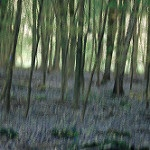

In [35]:
pat

In [36]:
pat=cv2.resize(pat,(256,256))

In [37]:
pat=pat.reshape(1,256,256,3)

In [38]:
predict=pat/255.

In [39]:
model.predict(predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[1.9282885e-07, 9.9999917e-01, 4.8001252e-09, 1.7797101e-13,
        1.1669127e-10, 5.8088881e-07]], dtype=float32)

In [40]:
import numpy as np

predicted_probabilities = model.predict(predict)
predicted_class_index = np.argmax(predicted_probabilities)
predicted_class_name = global_class_names[predicted_class_index]

print(f"The predicted category is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The predicted category is: forest
